In [39]:
# ============================================================
# PREDICTIVE MODELLING OF PARTICULATE MATTER
# USING MACHINE LEARNING IN OPENCAST COAL MINES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [40]:
# Upload all_stations_features.csv to Colab before running
df = pd.read_csv("all_stations_features.csv")
df["date"] = pd.to_datetime(df["date"])

# Drop lag and roll features
lag_roll_cols = [col for col in df.columns if 'lag' in col or 'roll' in col]
df = df.drop(columns=lag_roll_cols)

# Assign 3 seasons
df['month'] = df['date'].dt.month

def assign_season(month):
    if month in [3, 4, 5, 6]:
        return 'Summer'
    elif month in [7, 8, 9, 10]:
        return 'Monsoon'
    else:
        return 'Winter'

df['season'] = df['month'].apply(assign_season)

# Short station names
station_map = {
    'MIDC Khutala, Chandrapur - MPCB'       : 'Chandrapur',
    'Talcher Coalfields,Talcher - OSPCB'     : 'Talcher',
    'Vindhyachal STPS, Singrauli - MPPCB'   : 'Singrauli'
}
df['station_name'] = df['station'].map(station_map)

# Keep only needed columns
final_cols = ['date', 'station_name', 'season', 'month',
              'PM2.5', 'PM10',
              'temperature', 'humidity', 'wind_speed', 'wind_dir', 'rainfall',
              'NO2', 'NH3', 'CO', 'SO2']
df = df[final_cols]

print(f"✅ Dataset ready | Shape: {df.shape}")
print(f"📅 Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\n📍 Stations:\n{df['station_name'].value_counts()}")
print(f"\n🌦️  Seasons:\n{df['season'].value_counts()}")
print(f"\n🔍 Missing Values: {df.isnull().sum().sum()} (should be 0)")

✅ Dataset ready | Shape: (1051, 15)
📅 Date Range: 2019-01-04 to 2019-12-31

📍 Stations:
station_name
Singrauli     362
Talcher       347
Chandrapur    342
Name: count, dtype: int64

🌦️  Seasons:
season
Summer     362
Winter     347
Monsoon    342
Name: count, dtype: int64

🔍 Missing Values: 0 (should be 0)


In [41]:
# ============================================================
# STATION-WISE DESCRIPTIVE STATISTICS
# ============================================================

print("=" * 70)
print("DESCRIPTIVE STATISTICS — ALL VARIABLES")
print("=" * 70)
stats_cols = ['PM2.5','PM10','temperature','humidity',
              'wind_speed','rainfall','NO2','SO2','CO','NH3']
print(df[stats_cols].describe().round(2).to_string())

print("\n\n" + "=" * 70)
print("STATION-WISE MEAN VALUES")
print("=" * 70)
mean_table = df.groupby('station_name')[stats_cols].mean().round(2)
print(mean_table.to_string())

DESCRIPTIVE STATISTICS — ALL VARIABLES
         PM2.5     PM10  temperature  humidity  wind_speed  rainfall      NO2      SO2       CO      NH3
count  1051.00  1051.00      1051.00   1051.00     1051.00   1051.00  1051.00  1051.00  1051.00  1051.00
mean     54.63   149.06        26.65     65.88        6.71      3.23    24.95    26.25     1.01    14.19
std      42.52   111.45         5.12     19.49        7.06      9.79    29.62    19.11     0.76    12.85
min       1.00    12.78        10.00     16.00        0.47      0.00     0.03     0.45     0.00     0.11
25%      24.34    63.21        23.50     55.06        1.80      0.00     7.18     8.28     0.41     7.51
50%      41.00   104.89        26.97     70.77        2.74      0.00     9.54    26.17     0.81    12.87
75%      74.76   224.88        29.90     80.63       11.30      0.65    36.86    37.66     1.34    15.73
max     259.06   652.06        38.21     98.62       31.80    100.50   225.01   115.35     4.26   246.51


STATION-WISE M

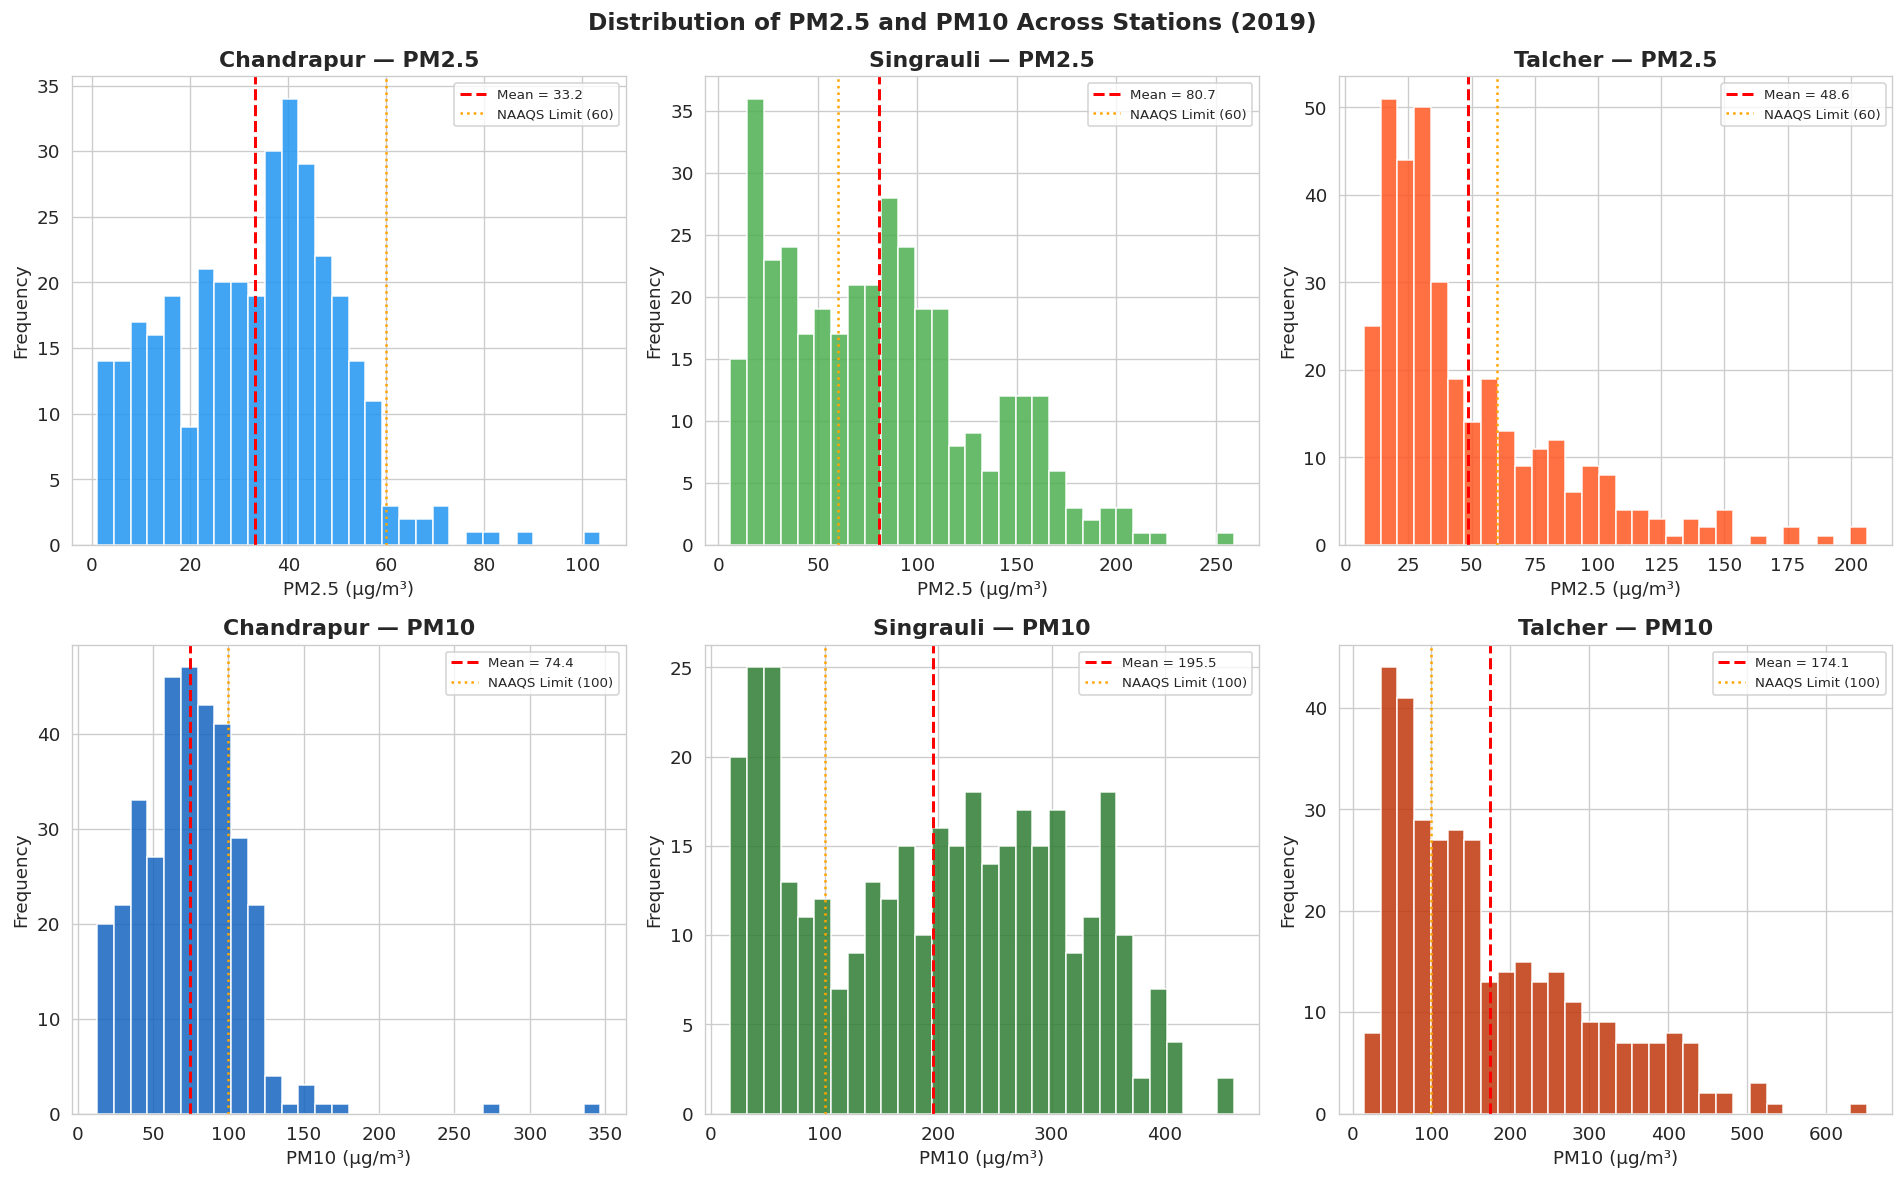

✅ Figure 1 saved


In [42]:
# ============================================================
# FIGURE 1: PM2.5 & PM10 DISTRIBUTIONS BY STATION
# ============================================================

station_colors = {'Chandrapur': '#2196F3', 'Singrauli': '#4CAF50', 'Talcher': '#FF5722'}
stations = ['Chandrapur', 'Singrauli', 'Talcher']
colors_pm25 = ['#2196F3', '#4CAF50', '#FF5722']
colors_pm10 = ['#1565C0', '#2E7D32', '#BF360C']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of PM2.5 and PM10 Across Stations (2019)',
             fontsize=14, fontweight='bold')

for i, (station, c1, c2) in enumerate(zip(stations, colors_pm25, colors_pm10)):
    data = df[df['station_name'] == station]

    axes[0, i].hist(data['PM2.5'], bins=30, color=c1, edgecolor='white', alpha=0.85)
    axes[0, i].axvline(data['PM2.5'].mean(), color='red',    linestyle='--', linewidth=1.8,
                       label=f"Mean = {data['PM2.5'].mean():.1f}")
    axes[0, i].axvline(60, color='orange', linestyle=':', linewidth=1.5,
                       label='NAAQS Limit (60)')
    axes[0, i].set_title(f'{station} — PM2.5', fontweight='bold')
    axes[0, i].set_xlabel('PM2.5 (µg/m³)')
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].legend(fontsize=8)

    axes[1, i].hist(data['PM10'], bins=30, color=c2, edgecolor='white', alpha=0.85)
    axes[1, i].axvline(data['PM10'].mean(), color='red',    linestyle='--', linewidth=1.8,
                       label=f"Mean = {data['PM10'].mean():.1f}")
    axes[1, i].axvline(100, color='orange', linestyle=':', linewidth=1.5,
                       label='NAAQS Limit (100)')
    axes[1, i].set_title(f'{station} — PM10', fontweight='bold')
    axes[1, i].set_xlabel('PM10 (µg/m³)')
    axes[1, i].set_ylabel('Frequency')
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_pm_distributions.png', bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved")

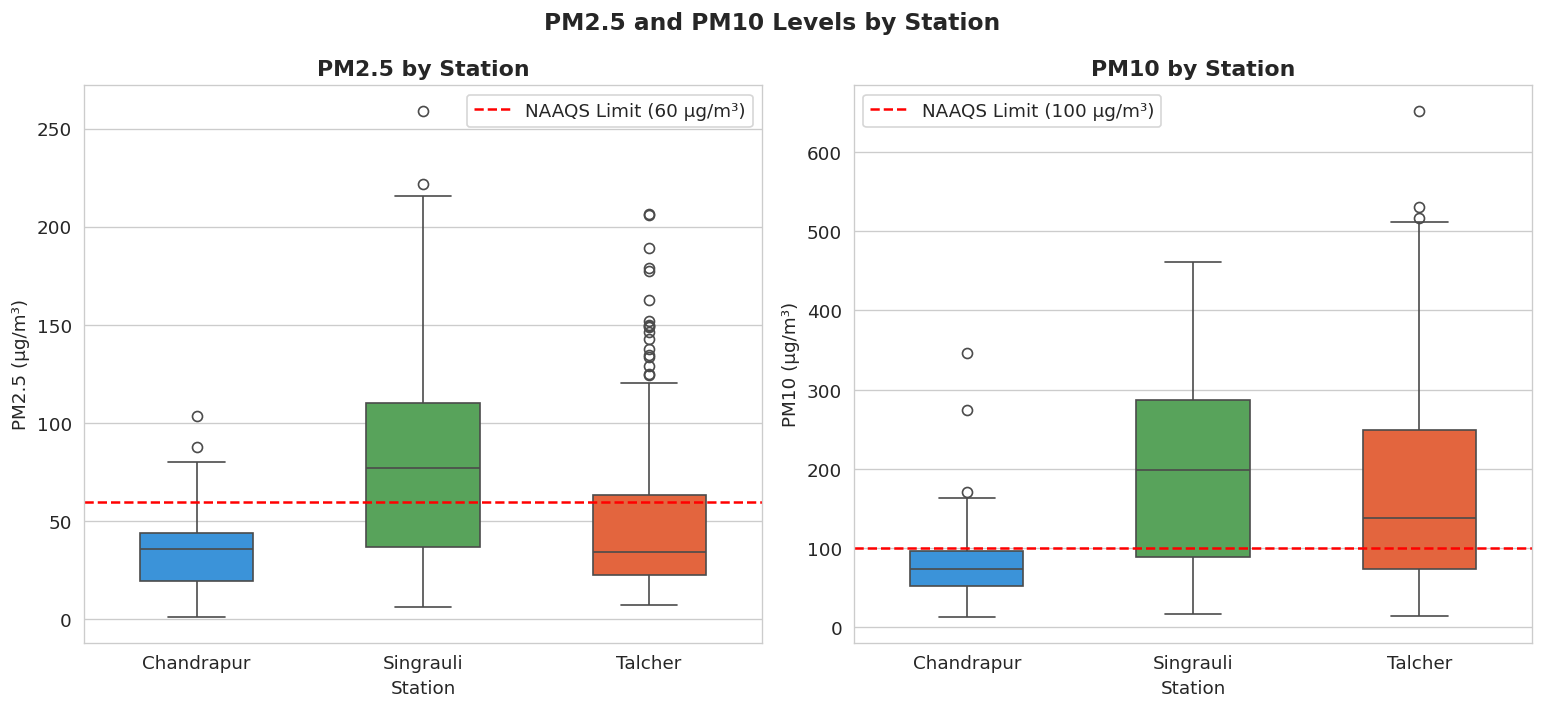

✅ Figure 2 saved


In [43]:
# ============================================================
# FIGURE 2: PM BOXPLOT BY STATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('PM2.5 and PM10 Levels by Station', fontsize=14, fontweight='bold')

palette = {'Chandrapur': '#2196F3', 'Singrauli': '#4CAF50', 'Talcher': '#FF5722'}

sns.boxplot(data=df, x='station_name', y='PM2.5', palette=palette,
            ax=axes[0], width=0.5, order=stations)
axes[0].axhline(60, color='red', linestyle='--', linewidth=1.5,
                label='NAAQS Limit (60 µg/m³)')
axes[0].set_title('PM2.5 by Station', fontweight='bold')
axes[0].set_xlabel('Station')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()

sns.boxplot(data=df, x='station_name', y='PM10', palette=palette,
            ax=axes[1], width=0.5, order=stations)
axes[1].axhline(100, color='red', linestyle='--', linewidth=1.5,
                label='NAAQS Limit (100 µg/m³)')
axes[1].set_title('PM10 by Station', fontweight='bold')
axes[1].set_xlabel('Station')
axes[1].set_ylabel('PM10 (µg/m³)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig2_pm_boxplot_station.png', bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved")

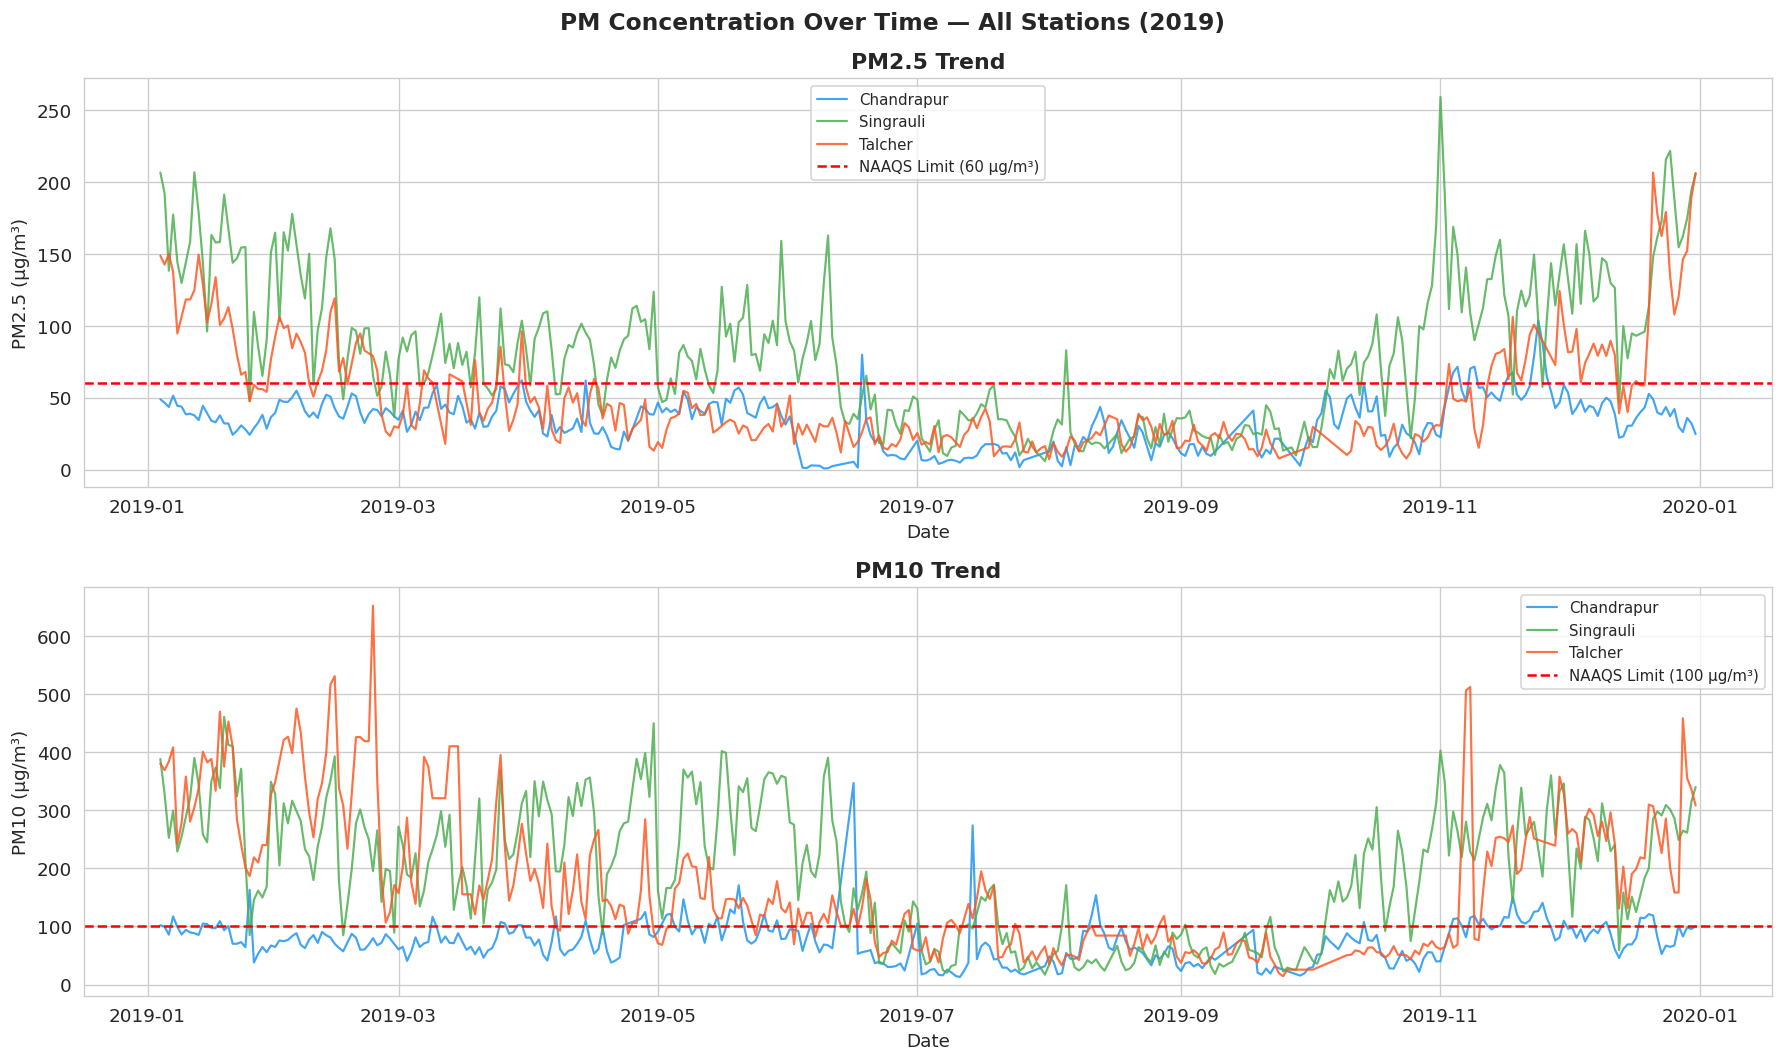

✅ Figure 3 saved


In [44]:
# ============================================================
# FIGURE 3: PM TIME SERIES TREND (2019)
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
fig.suptitle('PM Concentration Over Time — All Stations (2019)',
             fontsize=14, fontweight='bold')

for station, color in station_colors.items():
    subset = df[df['station_name'] == station].sort_values('date')
    axes[0].plot(subset['date'], subset['PM2.5'], label=station,
                 color=color, alpha=0.85, linewidth=1.3)
    axes[1].plot(subset['date'], subset['PM10'],  label=station,
                 color=color, alpha=0.85, linewidth=1.3)

axes[0].axhline(60,  color='red', linestyle='--', linewidth=1.5,
                label='NAAQS Limit (60 µg/m³)')
axes[1].axhline(100, color='red', linestyle='--', linewidth=1.5,
                label='NAAQS Limit (100 µg/m³)')

axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=11)
axes[0].set_title('PM2.5 Trend', fontweight='bold')
axes[1].set_ylabel('PM10 (µg/m³)', fontsize=11)
axes[1].set_title('PM10 Trend', fontweight='bold')

for ax in axes:
    ax.legend(fontsize=9)
    ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig('fig3_timeseries.png', bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved")

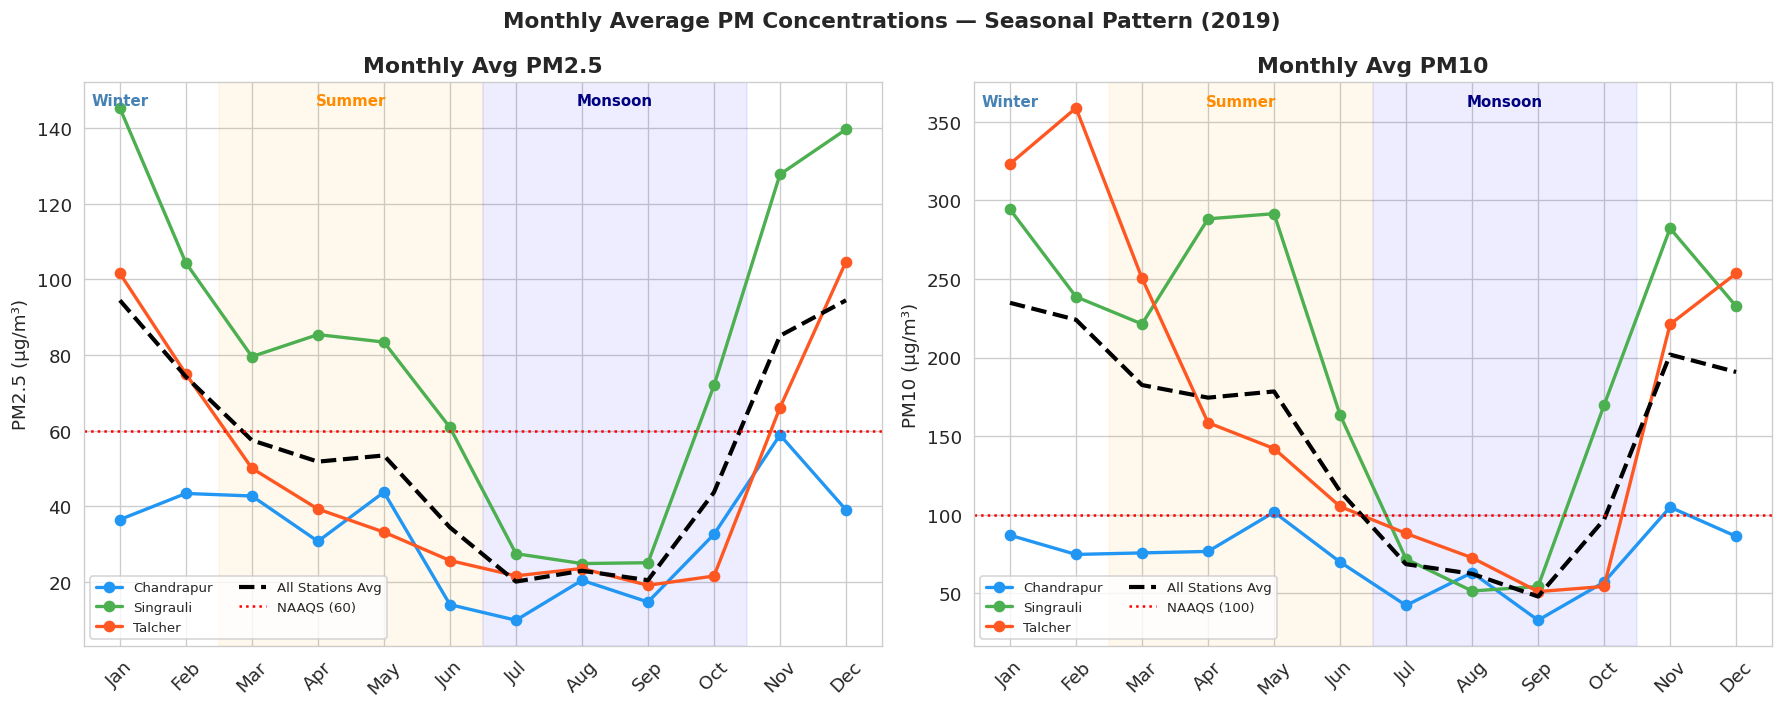

✅ Figure 4 saved


In [45]:
# ============================================================
# FIGURE 4: MONTHLY AVERAGE PM — SEASONAL PATTERN
# ============================================================

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_all      = df.groupby(['month','station_name'])[['PM2.5','PM10']].mean().reset_index()
monthly_combined = df.groupby('month')[['PM2.5','PM10']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Monthly Average PM Concentrations — Seasonal Pattern (2019)',
             fontsize=13, fontweight='bold')

for station, color in station_colors.items():
    sub = monthly_all[monthly_all['station_name'] == station]
    axes[0].plot(sub['month'], sub['PM2.5'], marker='o', label=station,
                 color=color, linewidth=2)
    axes[1].plot(sub['month'], sub['PM10'],  marker='o', label=station,
                 color=color, linewidth=2)

axes[0].plot(monthly_combined['month'], monthly_combined['PM2.5'],
             'k--', linewidth=2.5, label='All Stations Avg')
axes[1].plot(monthly_combined['month'], monthly_combined['PM10'],
             'k--', linewidth=2.5, label='All Stations Avg')

axes[0].axhline(60,  color='red', linestyle=':', linewidth=1.5, label='NAAQS (60)')
axes[1].axhline(100, color='red', linestyle=':', linewidth=1.5, label='NAAQS (100)')

for ax in axes:
    ax.axvspan(2.5,  6.5,  alpha=0.07, color='orange')  # Summer
    ax.axvspan(6.5, 10.5,  alpha=0.07, color='blue')    # Monsoon
    # Winter = white (Jan-Feb + Nov-Dec)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, rotation=45)
    ax.legend(fontsize=8, ncol=2)

# Add season labels on top
for ax in axes:
    ax.text(4.5,  ax.get_ylim()[1]*0.96, 'Summer',  ha='center',
            fontsize=9, color='darkorange', fontweight='bold')
    ax.text(8.5,  ax.get_ylim()[1]*0.96, 'Monsoon', ha='center',
            fontsize=9, color='navy',       fontweight='bold')
    ax.text(1.0,  ax.get_ylim()[1]*0.96, 'Winter',  ha='center',
            fontsize=9, color='steelblue',  fontweight='bold')

axes[0].set_ylabel('PM2.5 (µg/m³)'); axes[0].set_title('Monthly Avg PM2.5', fontweight='bold')
axes[1].set_ylabel('PM10 (µg/m³)');  axes[1].set_title('Monthly Avg PM10',  fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_monthly_avg.png', bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved")

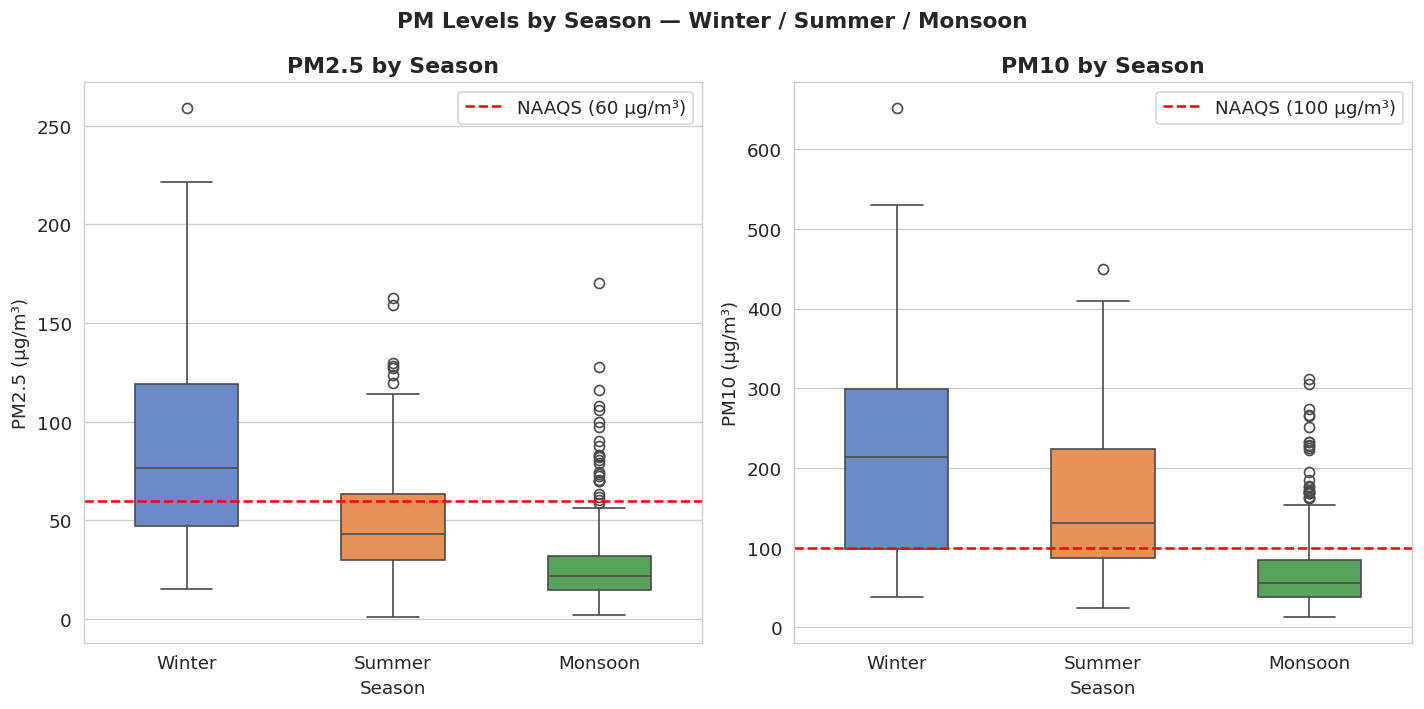

📊 Seasonal Mean PM Concentrations:
         PM2.5                  PM10                
          mean median    std    mean  median     std
season                                              
Winter   87.26  76.80  48.69  212.30  213.69  119.77
Summer   49.56  43.21  28.32  163.46  131.64   99.62
Monsoon  26.90  21.81  20.73   69.65   55.20   50.75


In [46]:
# ============================================================
# FIGURE 5: PM BY SEASON (BOXPLOT)
# ============================================================

season_order  = ['Winter', 'Summer', 'Monsoon']
season_colors = {'Winter': '#5C85D6', 'Summer': '#FF8C42', 'Monsoon': '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('PM Levels by Season — Winter / Summer / Monsoon',
             fontsize=13, fontweight='bold')

sns.boxplot(data=df, x='season', y='PM2.5', order=season_order,
            palette=season_colors, width=0.5, ax=axes[0])
axes[0].axhline(60, color='red', linestyle='--', linewidth=1.5,
                label='NAAQS (60 µg/m³)')
axes[0].set_title('PM2.5 by Season', fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xlabel('Season')
axes[0].legend()

sns.boxplot(data=df, x='season', y='PM10', order=season_order,
            palette=season_colors, width=0.5, ax=axes[1])
axes[1].axhline(100, color='red', linestyle='--', linewidth=1.5,
                label='NAAQS (100 µg/m³)')
axes[1].set_title('PM10 by Season', fontweight='bold')
axes[1].set_ylabel('PM10 (µg/m³)')
axes[1].set_xlabel('Season')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig5_seasonal_boxplot.png', bbox_inches='tight')
plt.show()

print("📊 Seasonal Mean PM Concentrations:")
print("=" * 40)
print(df.groupby('season')[['PM2.5','PM10']].agg(['mean','median','std']).round(2).loc[season_order])

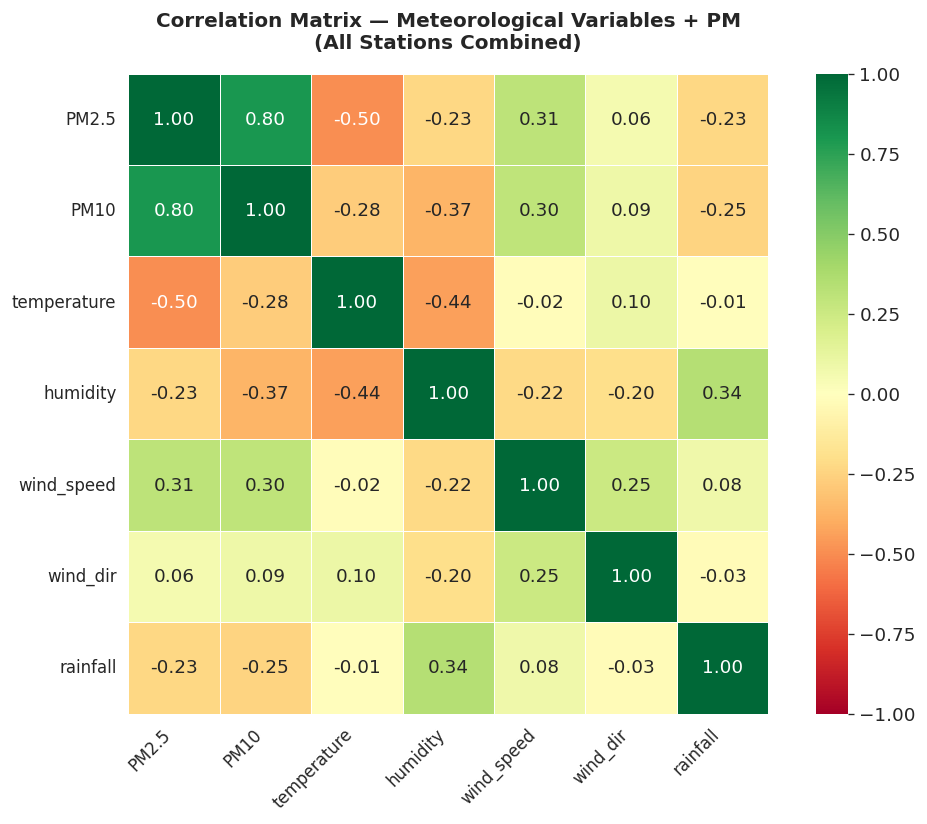

✅ Met-only heatmap saved!


In [47]:
# ============================================================
# MET-ONLY CORRELATION HEATMAP
# ============================================================

met_only_cols = ['PM2.5', 'PM10', 'temperature', 'humidity',
                 'wind_speed', 'wind_dir', 'rainfall']

corr_met = df[met_only_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_met,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation Matrix — Meteorological Variables + PM\n(All Stations Combined)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('fig6b_met_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Met-only heatmap saved!")

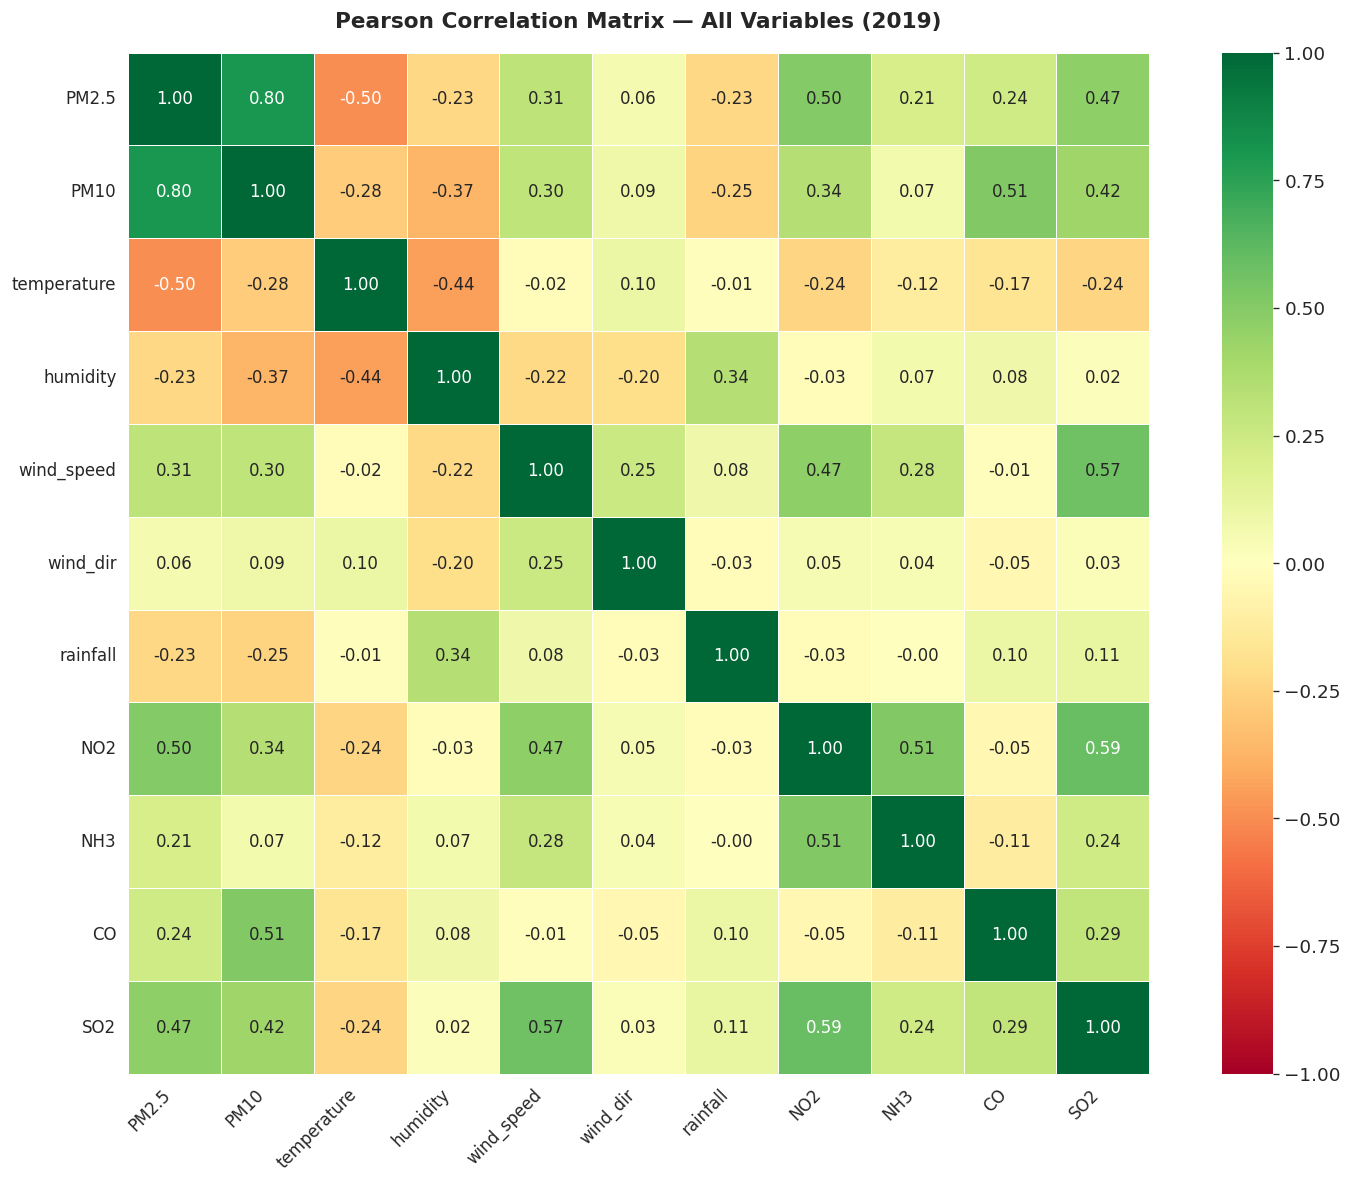

📊 Correlations with PM2.5 (sorted by strength):
PM10           0.80
temperature   -0.50
NO2            0.50
SO2            0.47
wind_speed     0.31
CO             0.24
humidity      -0.23
rainfall      -0.23
NH3            0.21
wind_dir       0.06

📊 Correlations with PM10 (sorted by strength):
PM2.5          0.80
CO             0.51
SO2            0.42
humidity      -0.37
NO2            0.34
wind_speed     0.30
temperature   -0.28
rainfall      -0.25
wind_dir       0.09
NH3            0.07


In [48]:
# ============================================================
# FIGURE 6: FULL CORRELATION HEATMAP
# ============================================================

corr_cols = ['PM2.5', 'PM10', 'temperature', 'humidity',
             'wind_speed', 'wind_dir', 'rainfall', 'NO2', 'NH3', 'CO', 'SO2']
corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            ax=ax, annot_kws={'size': 10})
ax.set_title('Pearson Correlation Matrix — All Variables (2019)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("📊 Correlations with PM2.5 (sorted by strength):")
print(corr['PM2.5'].drop('PM2.5').sort_values(key=abs, ascending=False).to_string())
print("\n📊 Correlations with PM10 (sorted by strength):")
print(corr['PM10'].drop('PM10').sort_values(key=abs, ascending=False).to_string())

NAAQS EXCEEDANCE  |  PM2.5: 60 µg/m³  |  PM10: 100 µg/m³

📍 Chandrapur  (n = 342 days)
   PM2.5 > 60  µg/m³ : 14 days  (4.1%)
   PM10  > 100 µg/m³ : 70 days  (20.5%)

📍 Singrauli  (n = 362 days)
   PM2.5 > 60  µg/m³ : 217 days  (59.9%)
   PM10  > 100 µg/m³ : 263 days  (72.7%)

📍 Talcher  (n = 347 days)
   PM2.5 > 60  µg/m³ : 96 days  (27.7%)
   PM10  > 100 µg/m³ : 224 days  (64.6%)


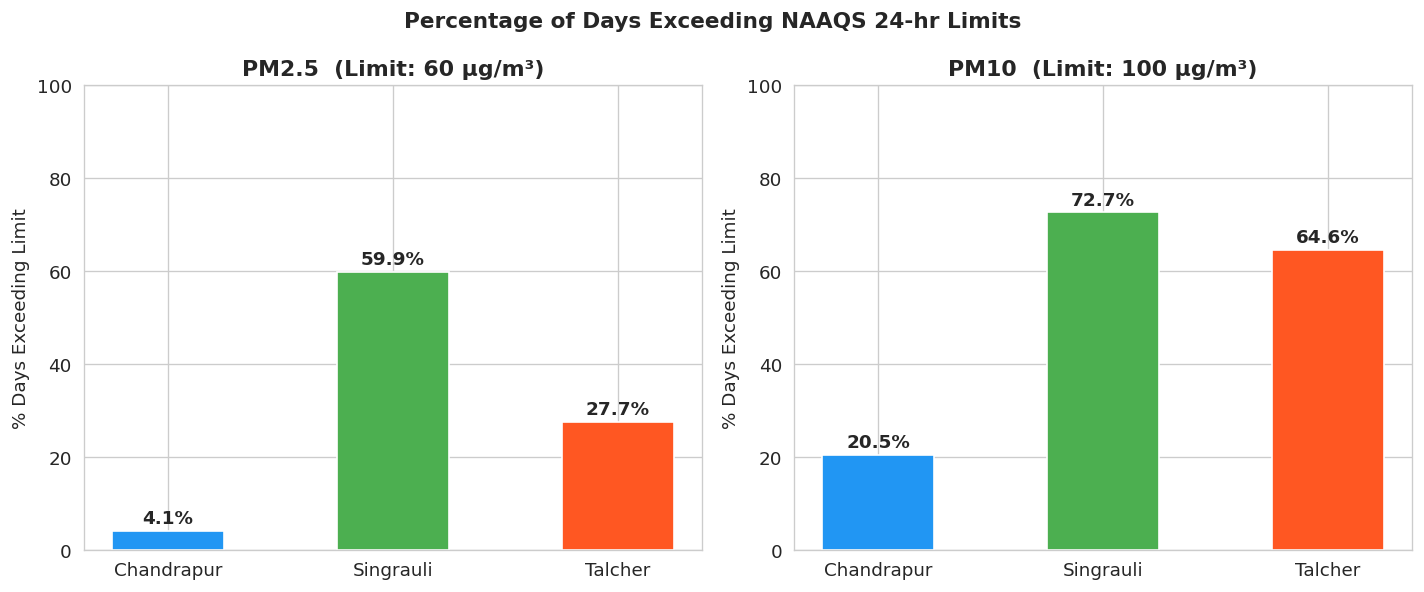

✅ Figure 7 saved — EDA COMPLETE ✅


In [49]:
# ============================================================
# FIGURE 7: NAAQS EXCEEDANCE ANALYSIS
# ============================================================

print("=" * 60)
print("NAAQS EXCEEDANCE  |  PM2.5: 60 µg/m³  |  PM10: 100 µg/m³")
print("=" * 60)

exc_data = []
for station in stations:
    sub   = df[df['station_name'] == station]
    total = len(sub)
    p25   = (sub['PM2.5'] > 60).sum()
    p10   = (sub['PM10']  > 100).sum()
    print(f"\n📍 {station}  (n = {total} days)")
    print(f"   PM2.5 > 60  µg/m³ : {p25} days  ({p25/total*100:.1f}%)")
    print(f"   PM10  > 100 µg/m³ : {p10} days  ({p10/total*100:.1f}%)")
    exc_data.append({'Station': station,
                     'PM2.5 Exceedance (%)': round(p25/total*100, 1),
                     'PM10 Exceedance (%)' : round(p10/total*100, 1)})

exc_df = pd.DataFrame(exc_data).set_index('Station')
bar_colors = ['#2196F3', '#4CAF50', '#FF5722']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Percentage of Days Exceeding NAAQS 24-hr Limits',
             fontsize=13, fontweight='bold')

for ax, col, title in zip(axes,
                           ['PM2.5 Exceedance (%)', 'PM10 Exceedance (%)'],
                           ['PM2.5  (Limit: 60 µg/m³)', 'PM10  (Limit: 100 µg/m³)']):
    bars = ax.bar(exc_df.index, exc_df[col], color=bar_colors,
                  edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('% Days Exceeding Limit')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, exc_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'{val}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig7_naaqs_exceedance.png', bbox_inches='tight')
plt.show()
print("✅ Figure 7 saved — EDA COMPLETE ✅")

In [50]:
# ============================================================
# MODEL BUILDING — SETUP
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ---- FEATURE SETS ----
met_features = ['temperature', 'humidity', 'wind_speed', 'wind_dir', 'rainfall']

met_gas_features = ['temperature', 'humidity', 'wind_speed', 'wind_dir', 'rainfall',
                    'NO2', 'SO2', 'CO', 'NH3']

print("✅ Models: Linear Regression | Decision Tree | Random Forest")
print("\n✅ Feature Set 1 — Met Only:")
print(met_features)
print("\n✅ Feature Set 2 — Met + Gas Pollutants:")
print(met_gas_features)
print(f"\nTotal samples : {len(df)}")
print(f"Training (80%): {int(len(df)*0.8)}")
print(f"Testing  (20%): {int(len(df)*0.2)}")

✅ Models: Linear Regression | Decision Tree | Random Forest

✅ Feature Set 1 — Met Only:
['temperature', 'humidity', 'wind_speed', 'wind_dir', 'rainfall']

✅ Feature Set 2 — Met + Gas Pollutants:
['temperature', 'humidity', 'wind_speed', 'wind_dir', 'rainfall', 'NO2', 'SO2', 'CO', 'NH3']

Total samples : 1051
Training (80%): 840
Testing  (20%): 210


In [51]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"   {name:<30} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f} ({r2*100:.1f}%)")
    return {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2': round(r2,4)}

def get_split(feature_cols, target_col):
    X = df[feature_cols]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

print("✅ Helper functions ready!")

✅ Helper functions ready!


In [52]:
# ============================================================
# FEATURE SET 1: MET ONLY
# Models: MLR, Decision Tree, Random Forest
# ============================================================

print("=" * 65)
print("  FEATURE SET 1: METEOROLOGICAL VARIABLES ONLY")
print("=" * 65)

results_met = {}

for target in ['PM2.5', 'PM10']:
    print(f"\n🎯 Target: {target}")
    print("-" * 55)
    X_train, X_test, y_train, y_test = get_split(met_features, target)
    results_met[target] = {}

    # Multiple Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    results_met[target]['MLR'] = evaluate_model(
        "Multiple Linear Regression", y_test, lr.predict(X_test))

    # Decision Tree
    dt = DecisionTreeRegressor(max_depth=6, random_state=42)
    dt.fit(X_train, y_train)
    results_met[target]['Decision Tree'] = evaluate_model(
        "Decision Tree", y_test, dt.predict(X_test))

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    results_met[target]['Random Forest'] = evaluate_model(
        "Random Forest", y_test, rf.predict(X_test))

print("\n✅ Feature Set 1 done!")

  FEATURE SET 1: METEOROLOGICAL VARIABLES ONLY

🎯 Target: PM2.5
-------------------------------------------------------
   Multiple Linear Regression     MAE=20.09  RMSE=27.55  R²=0.6056 (60.6%)
   Decision Tree                  MAE=16.28  RMSE=25.31  R²=0.6671 (66.7%)
   Random Forest                  MAE=13.31  RMSE=19.94  R²=0.7933 (79.3%)

🎯 Target: PM10
-------------------------------------------------------
   Multiple Linear Regression     MAE=63.61  RMSE=80.28  R²=0.4571 (45.7%)
   Decision Tree                  MAE=42.29  RMSE=63.60  R²=0.6593 (65.9%)
   Random Forest                  MAE=34.70  RMSE=49.63  R²=0.7925 (79.2%)

✅ Feature Set 1 done!


In [53]:
# ============================================================
# FEATURE SET 2: MET + GAS POLLUTANTS
# Models: MLR, Decision Tree, Random Forest
# ============================================================

print("=" * 65)
print("  FEATURE SET 2: MET + GAS POLLUTANTS")
print("=" * 65)

results_met_gas = {}
preds_store     = {}

for target in ['PM2.5', 'PM10']:
    print(f"\n🎯 Target: {target}")
    print("-" * 55)
    X_train, X_test, y_train, y_test = get_split(met_gas_features, target)
    results_met_gas[target] = {}
    preds_store[target] = {'y_test': y_test}

    # Multiple Linear Regression
    lr2 = LinearRegression()
    lr2.fit(X_train, y_train)
    p_lr = lr2.predict(X_test)
    results_met_gas[target]['MLR'] = evaluate_model(
        "Multiple Linear Regression", y_test, p_lr)
    preds_store[target]['MLR'] = p_lr

    # Decision Tree
    dt2 = DecisionTreeRegressor(max_depth=6, random_state=42)
    dt2.fit(X_train, y_train)
    p_dt = dt2.predict(X_test)
    results_met_gas[target]['Decision Tree'] = evaluate_model(
        "Decision Tree", y_test, p_dt)
    preds_store[target]['DT'] = p_dt

    # Random Forest
    rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf2.fit(X_train, y_train)
    p_rf = rf2.predict(X_test)
    results_met_gas[target]['Random Forest'] = evaluate_model(
        "Random Forest", y_test, p_rf)
    preds_store[target]['RF'] = p_rf

print("\n✅ Feature Set 2 done!")

  FEATURE SET 2: MET + GAS POLLUTANTS

🎯 Target: PM2.5
-------------------------------------------------------
   Multiple Linear Regression     MAE=17.48  RMSE=24.81  R²=0.6801 (68.0%)
   Decision Tree                  MAE=16.25  RMSE=24.32  R²=0.6926 (69.3%)
   Random Forest                  MAE=10.52  RMSE=16.96  R²=0.8505 (85.1%)

🎯 Target: PM10
-------------------------------------------------------
   Multiple Linear Regression     MAE=46.54  RMSE=58.25  R²=0.7142 (71.4%)
   Decision Tree                  MAE=37.52  RMSE=57.20  R²=0.7245 (72.4%)
   Random Forest                  MAE=26.53  RMSE=39.07  R²=0.8714 (87.1%)

✅ Feature Set 2 done!


In [54]:
# ============================================================
# COMPLETE RESULTS SUMMARY TABLE
# ============================================================

rows = []
for fset_name, fset_results in [('Met Only',  results_met),
                                  ('Met + Gas', results_met_gas)]:
    for target in ['PM2.5', 'PM10']:
        for model_name, metrics in fset_results[target].items():
            rows.append({
                'Feature Set' : fset_name,
                'Target'      : target,
                'Model'       : model_name,
                'R²'          : metrics['R2'],
                'MAE'         : metrics['MAE'],
                'RMSE'        : metrics['RMSE']
            })

results_df = pd.DataFrame(rows)

print("=" * 72)
print("       COMPLETE MODEL RESULTS — ALL MODELS, BOTH FEATURE SETS")
print("=" * 72)
print(results_df.to_string(index=False))
print("\n💡 R² closer to 1.0 = Better | MAE & RMSE lower = Better")

       COMPLETE MODEL RESULTS — ALL MODELS, BOTH FEATURE SETS
Feature Set Target         Model     R²   MAE  RMSE
   Met Only  PM2.5           MLR 0.6056 20.09 27.55
   Met Only  PM2.5 Decision Tree 0.6671 16.28 25.31
   Met Only  PM2.5 Random Forest 0.7933 13.31 19.94
   Met Only   PM10           MLR 0.4571 63.61 80.28
   Met Only   PM10 Decision Tree 0.6593 42.29 63.60
   Met Only   PM10 Random Forest 0.7925 34.70 49.63
  Met + Gas  PM2.5           MLR 0.6801 17.48 24.81
  Met + Gas  PM2.5 Decision Tree 0.6926 16.25 24.32
  Met + Gas  PM2.5 Random Forest 0.8505 10.52 16.96
  Met + Gas   PM10           MLR 0.7142 46.54 58.25
  Met + Gas   PM10 Decision Tree 0.7245 37.52 57.20
  Met + Gas   PM10 Random Forest 0.8714 26.53 39.07

💡 R² closer to 1.0 = Better | MAE & RMSE lower = Better


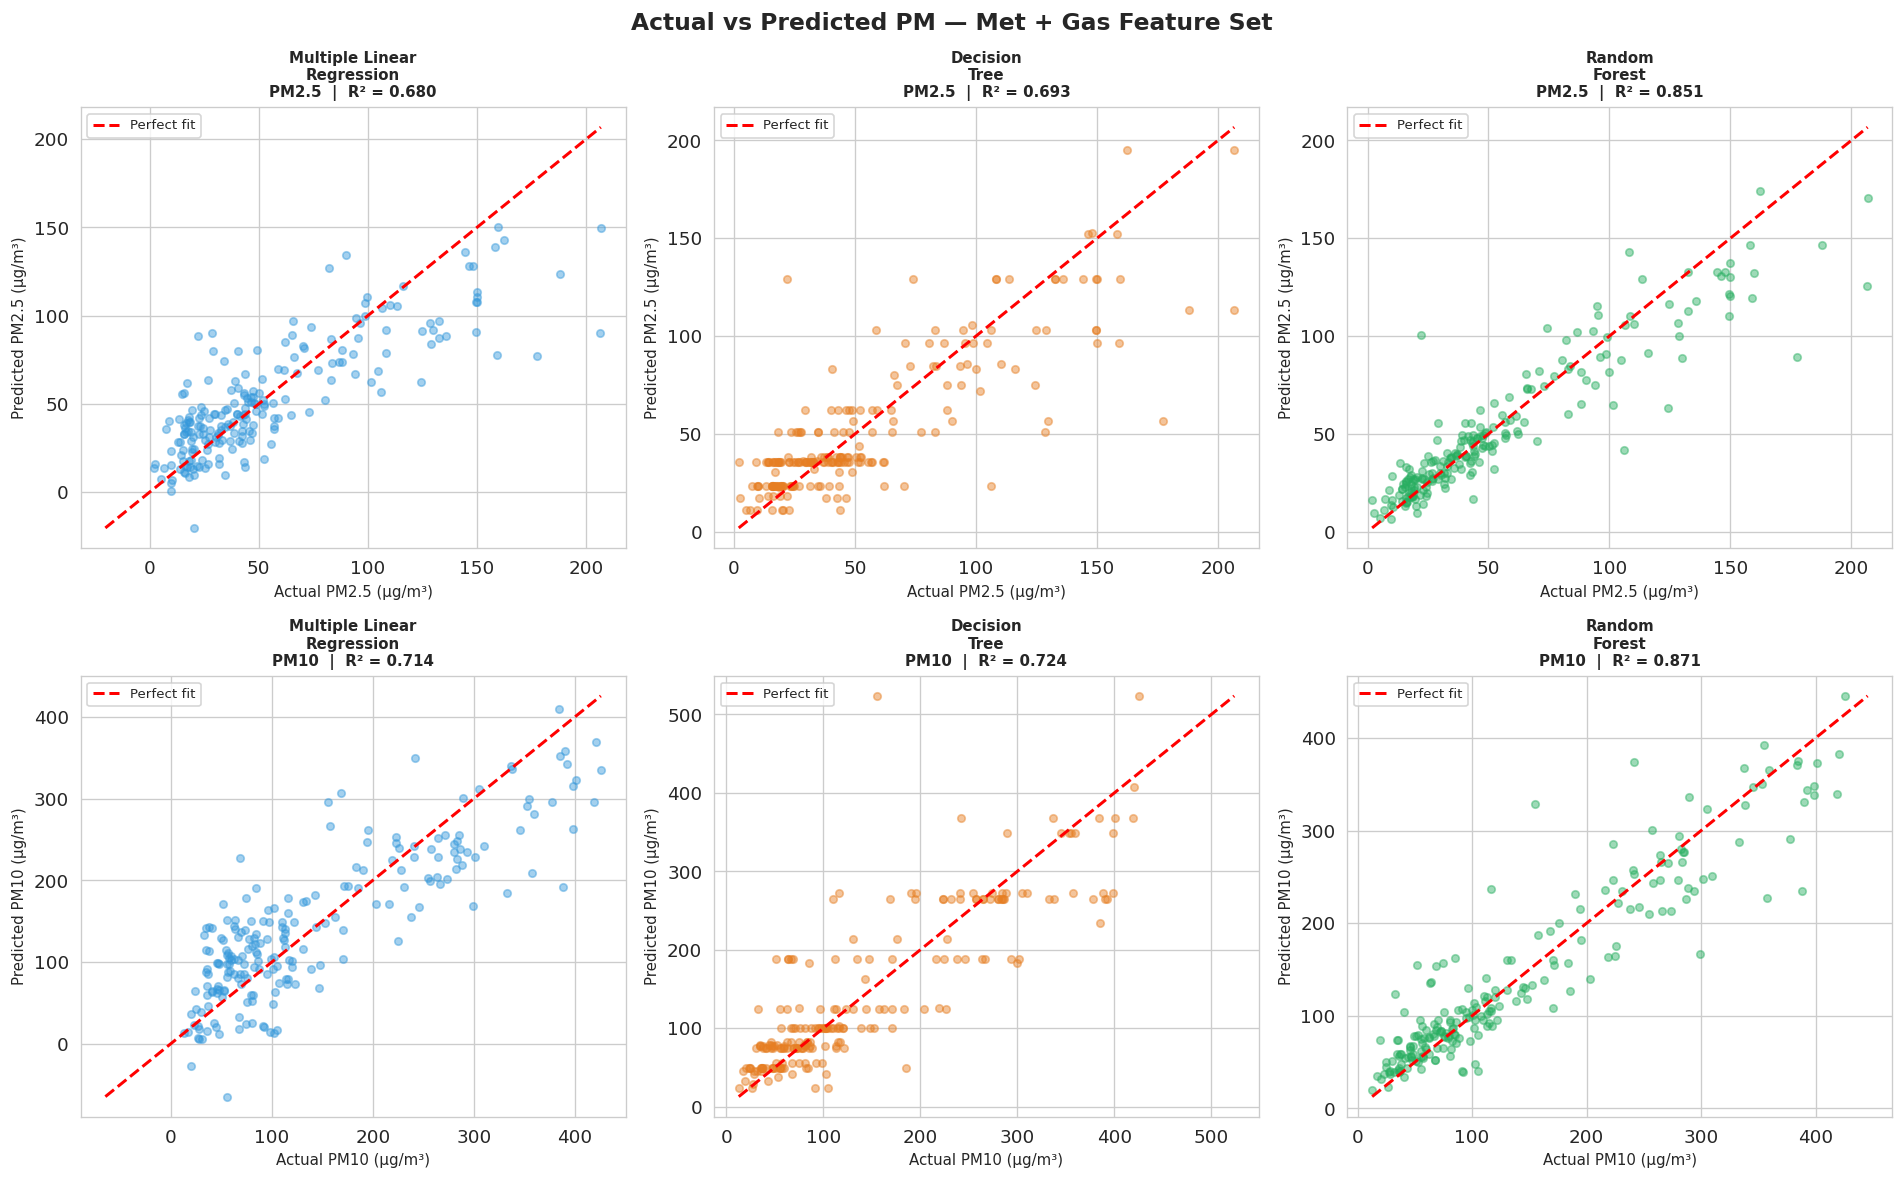

✅ Figure 8 saved: Actual vs Predicted


In [55]:
# ============================================================
# ACTUAL vs PREDICTED PLOTS — Met + Gas Feature Set
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Actual vs Predicted PM — Met + Gas Feature Set',
             fontsize=14, fontweight='bold')

model_keys   = ['MLR', 'DT',              'RF']
model_labels = ['Multiple Linear\nRegression', 'Decision\nTree', 'Random\nForest']
colors       = ['#3498DB', '#E67E22', '#27AE60']

for col, (mkey, mlab, color) in enumerate(zip(model_keys, model_labels, colors)):
    for row, target in enumerate(['PM2.5', 'PM10']):
        ax     = axes[row, col]
        y_true = preds_store[target]['y_test']
        y_pred = preds_store[target][mkey]
        r2_val = r2_score(y_true, y_pred)

        ax.scatter(y_true, y_pred, alpha=0.45, color=color, s=20)
        mn = min(y_true.min(), y_pred.min())
        mx = max(y_true.max(), y_pred.max())
        ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.8, label='Perfect fit')
        ax.set_xlabel(f'Actual {target} (µg/m³)', fontsize=9)
        ax.set_ylabel(f'Predicted {target} (µg/m³)', fontsize=9)
        ax.set_title(f'{mlab}\n{target}  |  R² = {r2_val:.3f}',
                     fontweight='bold', fontsize=9)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig8_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print("✅ Figure 8 saved: Actual vs Predicted")

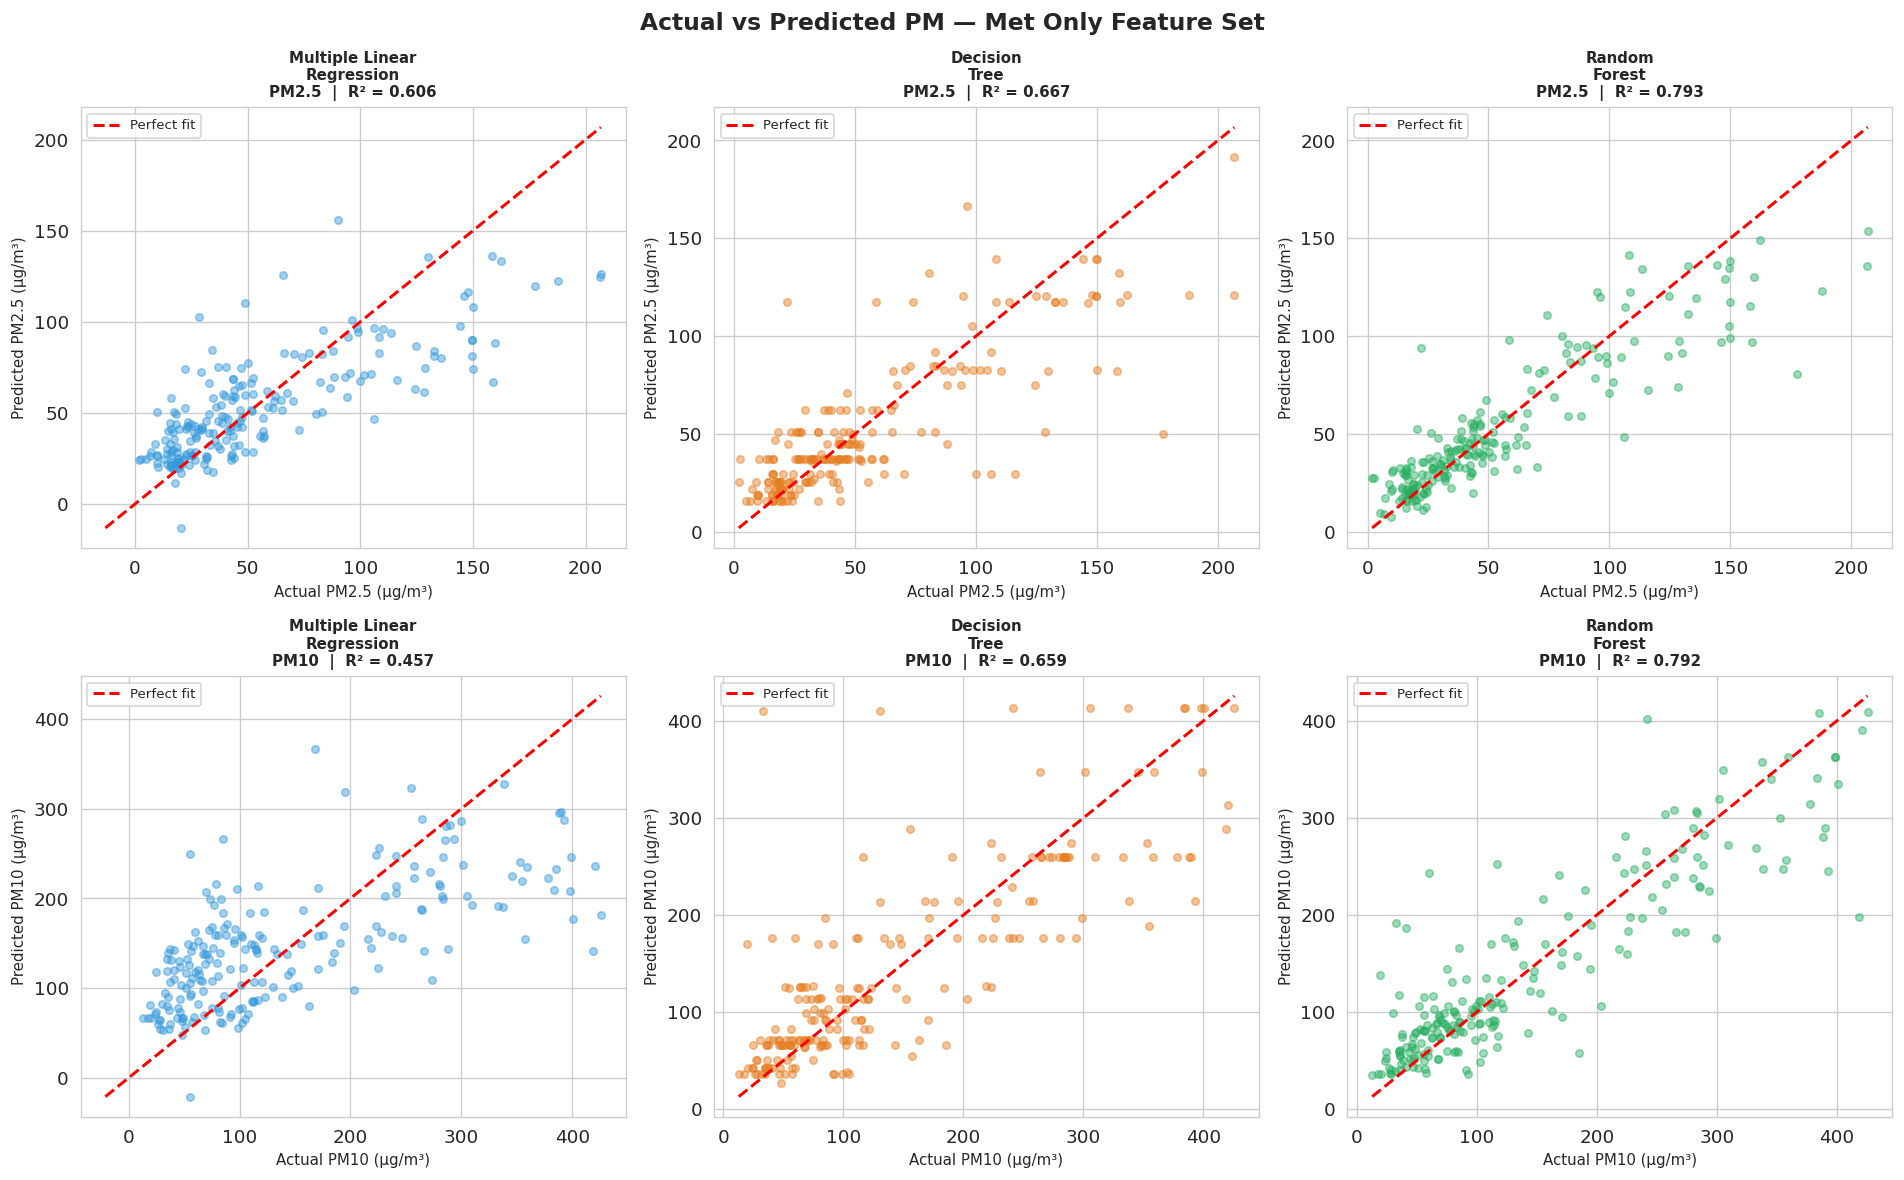

✅ Figure 8b saved: Actual vs Predicted — Met Only


In [56]:
# ============================================================
# ACTUAL vs PREDICTED PLOTS — Met Only Feature Set
# ============================================================

# Need predictions for met-only stored — run this to get them
preds_store_met = {}

for target in ['PM2.5', 'PM10']:
    X_train, X_test, y_train, y_test = get_split(met_features, target)
    preds_store_met[target] = {'y_test': y_test}

    lr_m = LinearRegression()
    lr_m.fit(X_train, y_train)
    preds_store_met[target]['MLR'] = lr_m.predict(X_test)

    dt_m = DecisionTreeRegressor(max_depth=6, random_state=42)
    dt_m.fit(X_train, y_train)
    preds_store_met[target]['DT'] = dt_m.predict(X_test)

    rf_m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_m.fit(X_train, y_train)
    preds_store_met[target]['RF'] = rf_m.predict(X_test)

# ---- Plot ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Actual vs Predicted PM — Met Only Feature Set',
             fontsize=14, fontweight='bold')

model_keys   = ['MLR', 'DT',        'RF']
model_labels = ['Multiple Linear\nRegression', 'Decision\nTree', 'Random\nForest']
colors       = ['#3498DB', '#E67E22', '#27AE60']

for col, (mkey, mlab, color) in enumerate(zip(model_keys, model_labels, colors)):
    for row, target in enumerate(['PM2.5', 'PM10']):
        ax     = axes[row, col]
        y_true = preds_store_met[target]['y_test']
        y_pred = preds_store_met[target][mkey]
        r2_val = r2_score(y_true, y_pred)

        ax.scatter(y_true, y_pred, alpha=0.45, color=color, s=20)
        mn = min(y_true.min(), y_pred.min())
        mx = max(y_true.max(), y_pred.max())
        ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.8, label='Perfect fit')
        ax.set_xlabel(f'Actual {target} (µg/m³)', fontsize=9)
        ax.set_ylabel(f'Predicted {target} (µg/m³)', fontsize=9)
        ax.set_title(f'{mlab}\n{target}  |  R² = {r2_val:.3f}',
                     fontweight='bold', fontsize=9)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig8b_actual_vs_predicted_met_only.png', bbox_inches='tight')
plt.show()
print("✅ Figure 8b saved: Actual vs Predicted — Met Only")

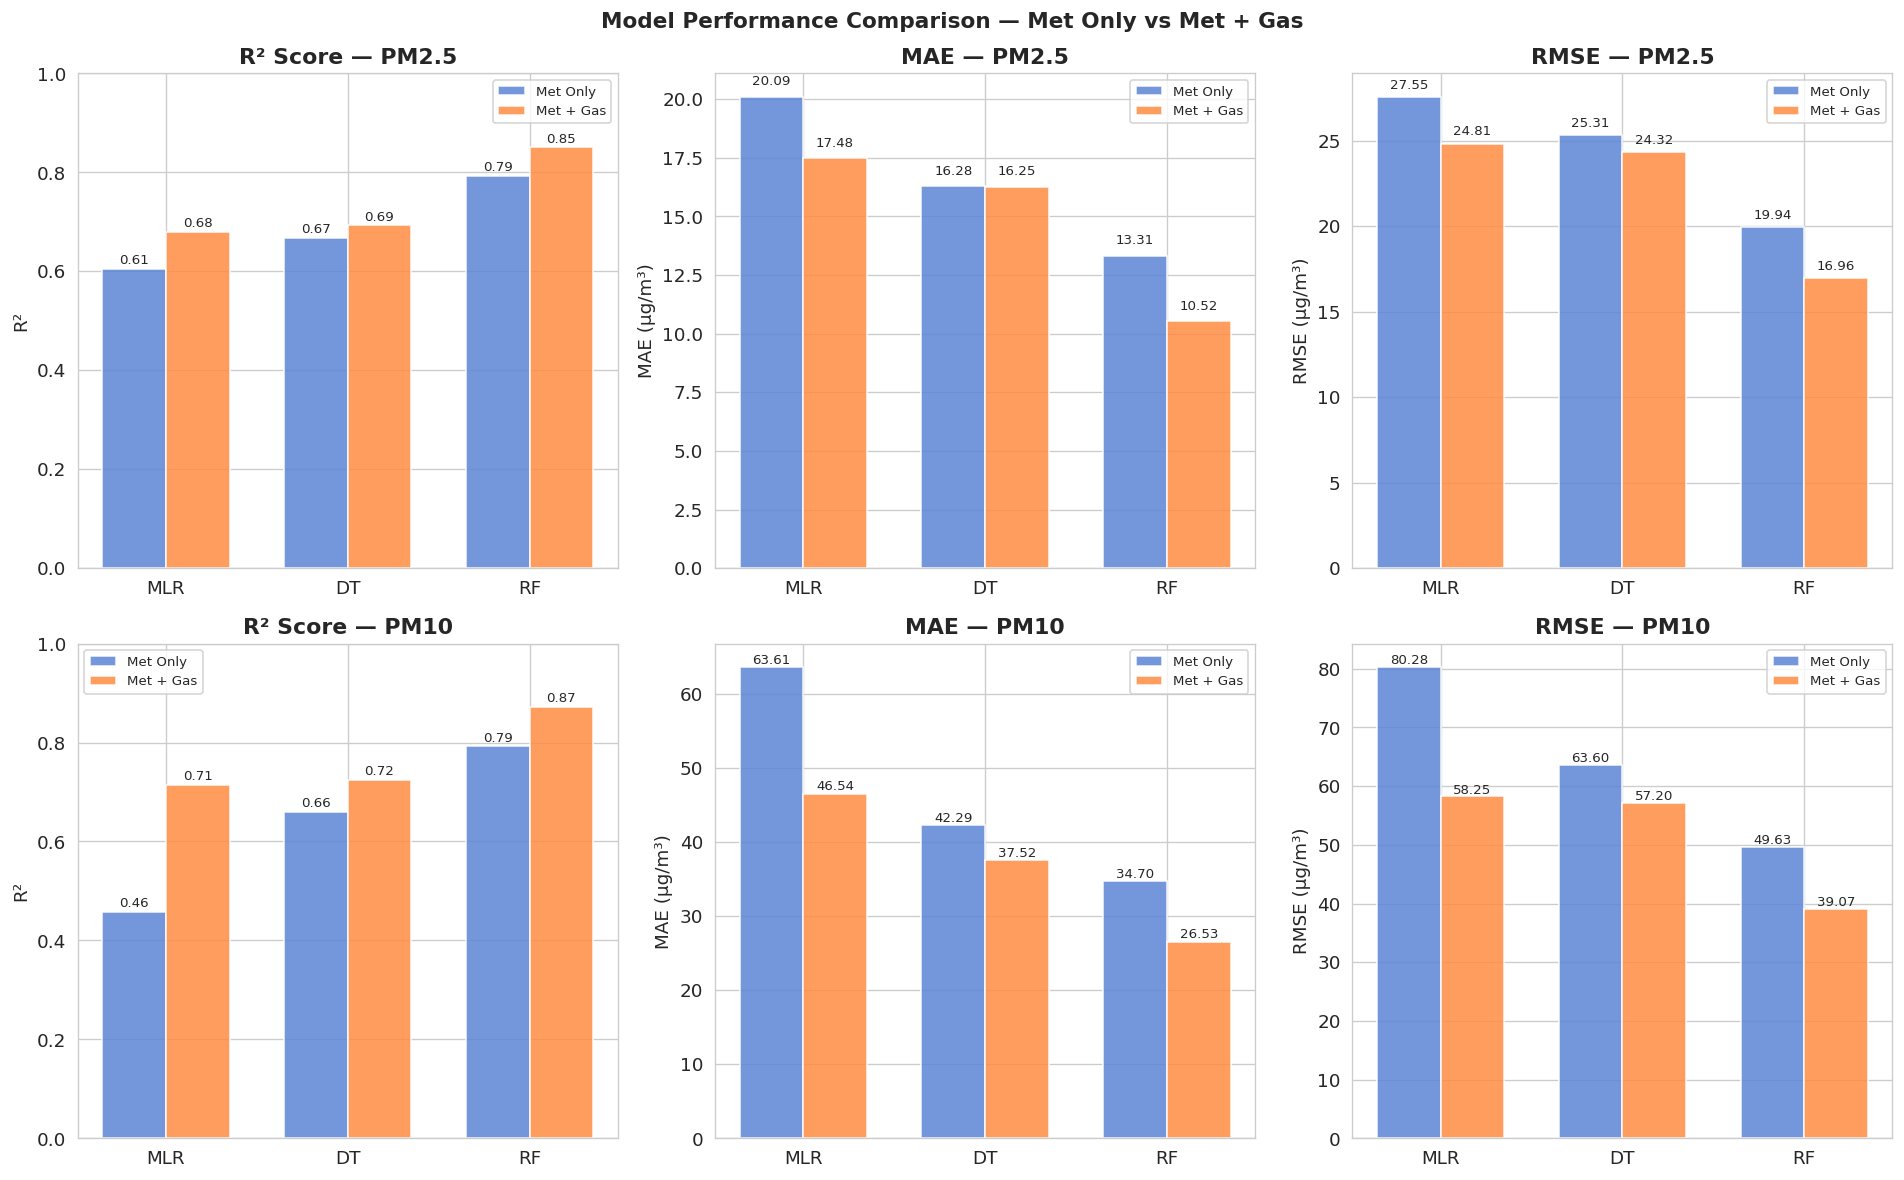

✅ Figure 9 saved: Model Comparison


In [57]:
# ============================================================
# MODEL COMPARISON BAR CHART
# ============================================================

model_list = ['MLR', 'Decision Tree', 'Random Forest']
xlabels    = ['MLR', 'DT', 'RF']
x          = np.arange(len(model_list))
width      = 0.35

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Performance Comparison — Met Only vs Met + Gas',
             fontsize=13, fontweight='bold')

for row, target in enumerate(['PM2.5', 'PM10']):
    r2_met   = [results_met[target][m]['R2']   for m in model_list]
    r2_mg    = [results_met_gas[target][m]['R2']   for m in model_list]
    mae_met  = [results_met[target][m]['MAE']  for m in model_list]
    mae_mg   = [results_met_gas[target][m]['MAE']  for m in model_list]
    rmse_met = [results_met[target][m]['RMSE'] for m in model_list]
    rmse_mg  = [results_met_gas[target][m]['RMSE'] for m in model_list]

    for col, (met_v, mg_v, ylabel, metric) in enumerate([
        (r2_met,   r2_mg,   'R²',           'R² Score'),
        (mae_met,  mae_mg,  'MAE (µg/m³)',  'MAE'),
        (rmse_met, rmse_mg, 'RMSE (µg/m³)', 'RMSE')
    ]):
        ax = axes[row, col]
        ax.bar(x - width/2, met_v, width, label='Met Only',
               color='#5C85D6', alpha=0.85, edgecolor='white')
        ax.bar(x + width/2, mg_v,  width, label='Met + Gas',
               color='#FF8C42', alpha=0.85, edgecolor='white')
        ax.set_title(f'{metric} — {target}', fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_ylabel(ylabel)
        if metric == 'R² Score':
            ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        offset = 0.01 if metric == 'R² Score' else 0.5
        for i, (a, b) in enumerate(zip(met_v, mg_v)):
            ax.text(i-width/2, a+offset, f'{a:.2f}', ha='center', fontsize=8)
            ax.text(i+width/2, b+offset, f'{b:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig9_model_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Figure 9 saved: Model Comparison")

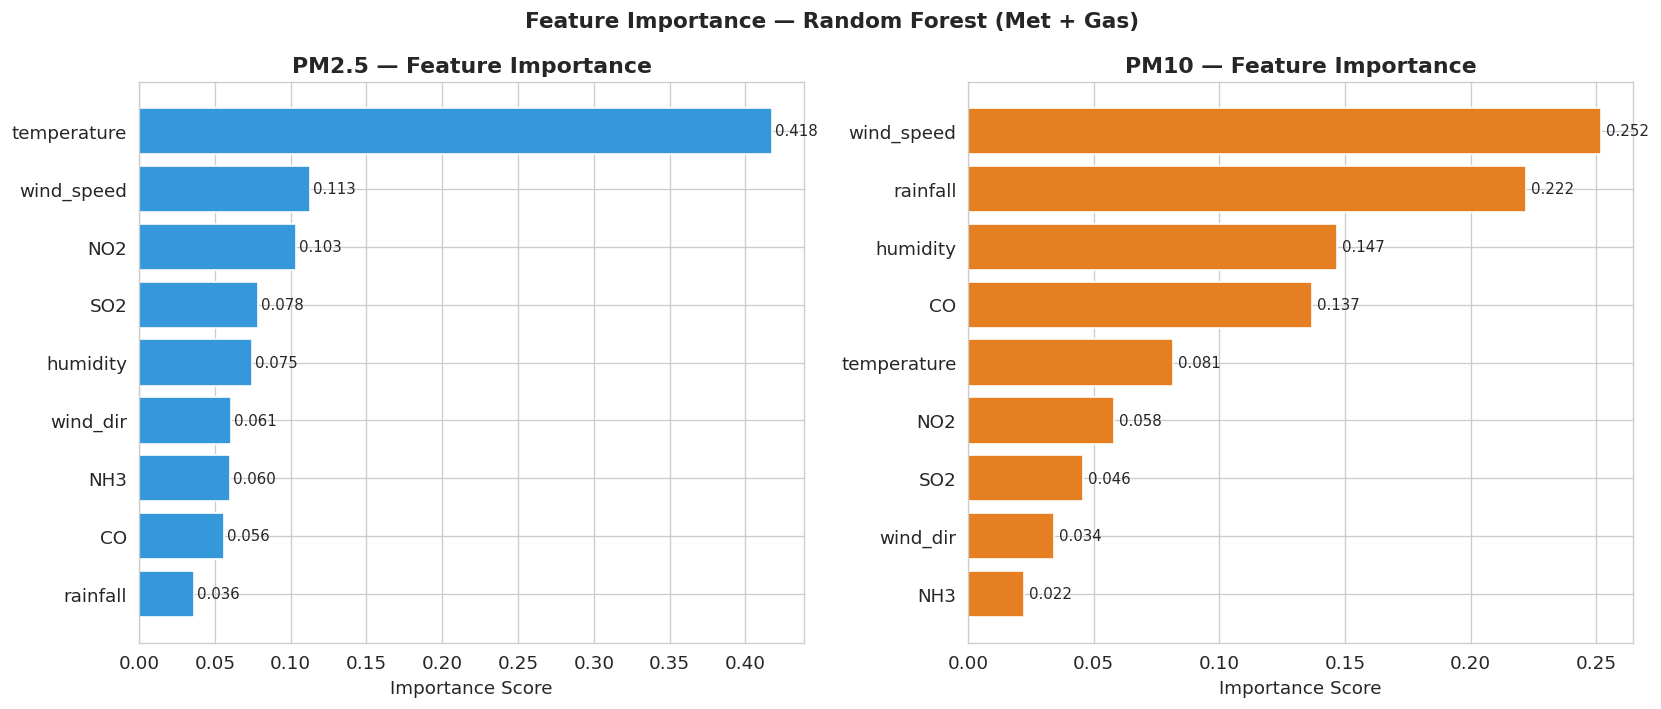


📊 PM2.5 Feature Importance:
    Feature  Importance
temperature    0.417741
 wind_speed    0.113020
        NO2    0.103393
        SO2    0.078230
   humidity    0.074577
   wind_dir    0.060949
        NH3    0.060042
         CO    0.055983
   rainfall    0.036063

📊 PM10 Feature Importance:
    Feature  Importance
 wind_speed    0.252015
   rainfall    0.222082
   humidity    0.146892
         CO    0.136931
temperature    0.081442
        NO2    0.058076
        SO2    0.045891
   wind_dir    0.034339
        NH3    0.022332


In [58]:
# ============================================================
# FEATURE IMPORTANCE — RANDOM FOREST (Met + Gas)
# ============================================================

X_tr, X_te, y_tr25, y_te25 = get_split(met_gas_features, 'PM2.5')
X_tr, X_te, y_tr10, y_te10 = get_split(met_gas_features, 'PM10')

rf_25 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_10 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_25.fit(X_tr, y_tr25)
rf_10.fit(X_tr, y_tr10)

imp_25 = pd.DataFrame({'Feature': met_gas_features,
                        'Importance': rf_25.feature_importances_}
                      ).sort_values('Importance', ascending=True)
imp_10 = pd.DataFrame({'Feature': met_gas_features,
                        'Importance': rf_10.feature_importances_}
                      ).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance — Random Forest (Met + Gas)',
             fontsize=13, fontweight='bold')

for ax, imp, target, color in zip(
        axes, [imp_25, imp_10], ['PM2.5', 'PM10'], ['#3498DB', '#E67E22']):
    ax.barh(imp['Feature'], imp['Importance'], color=color, edgecolor='white')
    ax.set_title(f'{target} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, v in enumerate(imp['Importance']):
        ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig10_feature_importance.png', bbox_inches='tight')
plt.show()

print("\n📊 PM2.5 Feature Importance:")
print(imp_25.sort_values('Importance', ascending=False).to_string(index=False))
print("\n📊 PM10 Feature Importance:")
print(imp_10.sort_values('Importance', ascending=False).to_string(index=False))

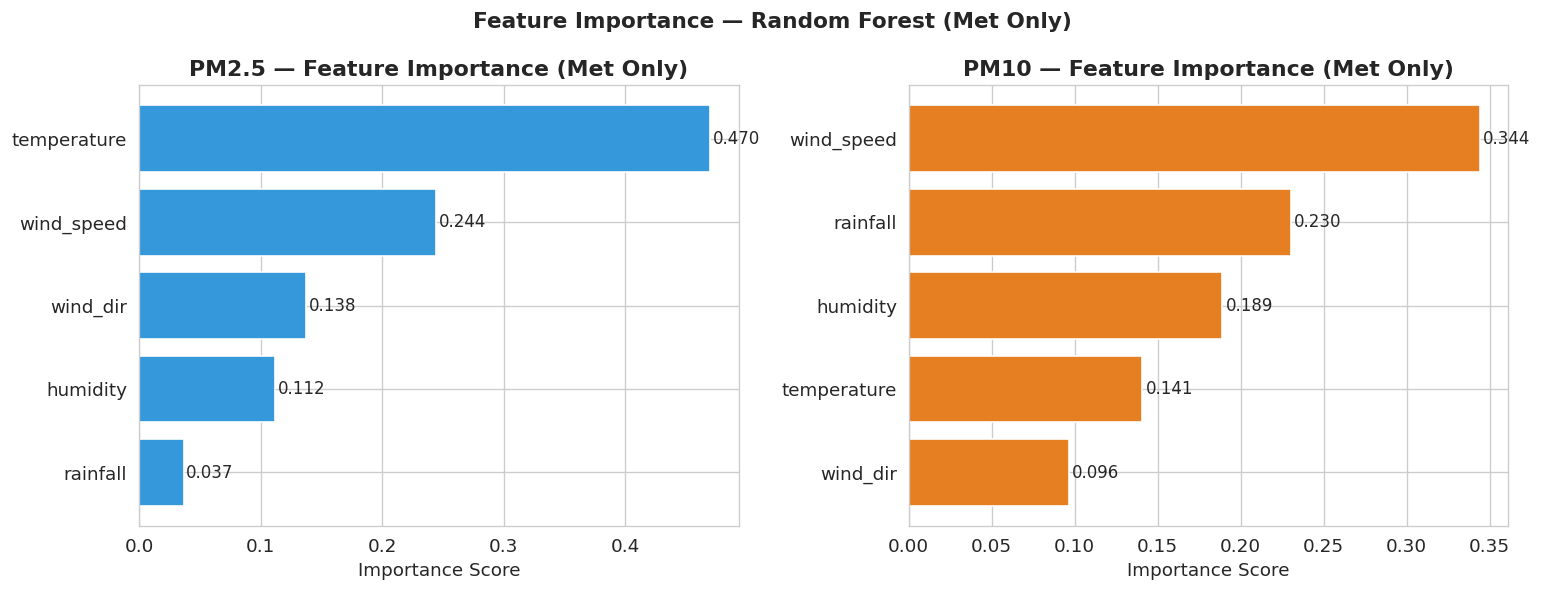


📊 PM2.5 Feature Importance (Met Only — Random Forest):
    Feature  Importance
temperature    0.469554
 wind_speed    0.244248
   wind_dir    0.137609
   humidity    0.111996
   rainfall    0.036592

📊 PM10 Feature Importance (Met Only — Random Forest):
    Feature  Importance
 wind_speed    0.343883
   rainfall    0.230184
   humidity    0.188870
temperature    0.140598
   wind_dir    0.096465


In [59]:
# ============================================================
# FEATURE IMPORTANCE — RANDOM FOREST (Met Only)
# ============================================================

X_tr_m, X_te_m, y_tr25_m, y_te25_m = get_split(met_features, 'PM2.5')
X_tr_m, X_te_m, y_tr10_m, y_te10_m = get_split(met_features, 'PM10')

rf_met_25 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_met_10 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_met_25.fit(X_tr_m, y_tr25_m)
rf_met_10.fit(X_tr_m, y_tr10_m)

imp_met_25 = pd.DataFrame({'Feature': met_features,
                            'Importance': rf_met_25.feature_importances_}
                          ).sort_values('Importance', ascending=True)

imp_met_10 = pd.DataFrame({'Feature': met_features,
                            'Importance': rf_met_10.feature_importances_}
                          ).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Feature Importance — Random Forest (Met Only)',  # <-- corrected title
             fontsize=13, fontweight='bold')

for ax, imp, target, color in zip(
        axes,
        [imp_met_25, imp_met_10],
        ['PM2.5', 'PM10'],
        ['#3498DB', '#E67E22']):
    ax.barh(imp['Feature'], imp['Importance'], color=color, edgecolor='white')
    ax.set_title(f'{target} — Feature Importance (Met Only)', fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, v in enumerate(imp['Importance']):
        ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig10b_feature_importance_met_only.png', bbox_inches='tight')
plt.show()

print("\n📊 PM2.5 Feature Importance (Met Only — Random Forest):")
print(imp_met_25.sort_values('Importance', ascending=False).to_string(index=False))
print("\n📊 PM10 Feature Importance (Met Only — Random Forest):")
print(imp_met_10.sort_values('Importance', ascending=False).to_string(index=False))